In [380]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


In [381]:
# Upload the cleaned and sampled dataset
df = pd.read_excel('../data/properties_sampled.xlsx')

## Transform data - feature engineering

In [382]:
# Zamień kolumnę 'construction_year' na 'building_age' (wiek mieszkania)
current_year = pd.Timestamp.now().year
df['building_age'] = current_year - df['construction_year']
df = df.drop(columns=['construction_year'])

### Transform latitute and logitutate into districts

In [383]:
# Load districts GeoJSON
districts = gpd.read_file("../data/warszawa-dzielnice.geojson")
districts = districts.to_crs(epsg=4326) 

In [384]:
# Exclude 'Warszawa' district from the analysis as it is not a valid district
districts = districts[districts['name'] != 'Warszawa']

In [385]:
# Create GeoDataFrame from df points
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Spatial join: find district for each point
result = gpd.sjoin(df_gdf, districts, how='left', predicate='within')

In [386]:
# Remove duplicate index by grouping and taking the first match
district_series = result.groupby(result.index)['name'].first()
df['district'] = district_series

In [387]:
# Remove rows where district could not be assigned (i.e., district is NaN)
df = df[df['district'].notna()]

### Odległość od metra

In [388]:
stations = [
    ("Kabaty", 52.131222, 21.065824),
    ("Natolin", 52.140203, 21.057709),
    ("Imielin", 52.149919, 21.045560),
    ("Stokłosy", 52.156010, 21.034454),
    ("Ursynów", 52.161899, 21.027310),
    ("Służew", 52.173098, 21.026369),
    ("Wilanowska", 52.181673, 21.022982),
    ("Wierzbno", 52.189900, 21.016825),
    ("Racławicka", 52.199369, 21.012154),
    ("Pole Mokotowskie", 52.208606, 21.007864),
    ("Politechnika", 52.217619, 21.014673),
    ("Centrum", 52.229812, 21.011643),
    ("Świętokrzyska", 52.235270, 21.008575),
    ("Ratusz Arsenał", 52.244610, 21.001224),
    ("Dworzec Gdański", 52.258080, 20.994779),
    ("Plac Wilsona", 52.268823, 20.985170),
    ("Marymont", 52.271893, 20.970699),
    ("Słodowiec", 52.276942, 20.960029),
    ("Stare Bielany", 52.281706, 20.949219),
    ("Wawrzyszew", 52.286273, 20.939508),
    ("Młociny", 52.290646, 20.930182),
    ("Bemowo", 52.239227, 20.915040),
    ("Ulrychów", 52.240358, 20.930003),
    ("Księcia Janusza", 52.239166, 20.942638),
    ("Młynów", 52.237543, 20.960662),
    ("Płocka", 52.232800, 20.965934),
    ("Rondo Daszyńskiego", 52.230420, 20.983315),
    ("Rondo ONZ", 52.233150, 20.998176),
    ("Nowy Świat-Uniwersytet", 52.237030, 21.017660),
    ("Centrum Nauki Kopernik", 52.239538, 21.031238),
    ("Stadion Narodowy", 52.246919, 21.043167),
    ("Dworzec Wileński", 52.254154, 21.035130),
    ("Szwedzka", 52.263355, 21.045245),
    ("Targówek Mieszkaniowy", 52.269588, 21.051441),
    ("Trocka", 52.275312, 21.055723),
    ("Zacisze", 52.284251, 21.062036),
    ("Kondratowicza", 52.292042, 21.050196),
    ("Bródno", 52.293518, 21.029058)
]

In [389]:
station_coords = np.array([(lat, lon) for _, lat, lon in stations])

def min_station_distance(row):
    dists = np.sqrt((station_coords[:, 0] - row['latitude'])**2 + (station_coords[:, 1] - row['longitude'])**2)
    return dists.min()

df['dist_to_metro'] = df.apply(min_station_distance, axis=1)


### Odległość od centrum

In [390]:

# Find coordinates of "Centrum" station
centrum_station = next((lat, lon) for name, lat, lon in stations if name == "Centrum")

# Calculate Euclidean distance from each row to "Centrum" station
df['dist_to_center'] = np.sqrt(
    (df['latitude'] - centrum_station[0])**2 + (df['longitude'] - centrum_station[1])**2
)


### Zachodnia i wschodnia strona wisły

In [391]:
left_side_districts = {
    'Śródmieście', 'Mokotów', 'Wola', 'Ochota', 'Ursynów', 'Włochy', 'Bemowo',
    'Wilanów', 'Ursus', 'Bielany', 'Żoliborz'
}

right_side_districts = {
    'Praga Północ', 'Praga Południe', 'Targówek', 'Białołęka',
    'Rembertów', 'Wesoła', 'Wawer'
}

In [392]:
def map_river_side(district):
    if district in left_side_districts:
        return 0 # west
    elif district in right_side_districts:
        return 1 # east
    else:
        raise ValueError(f"District '{district}' not found in either side mapping.")

df['river_side'] = df['district'].apply(map_river_side)


In [393]:
# Drop unnecessary columns
df = df.drop(columns=['geometry', 'latitude', 'longitude'])

### Feature grouping — material groups

In [394]:
#  Material groups 
MATERIAL_GROUPS = {
    'wielka płyta': 'prefab',
    'cegła':        'brick',
    'pustak':       'brick',
    'silikat':      'brick',
    'ytong':        'modern',
    'rama h':       'modern',
    'drewno':       'other',
    'inny':         'other',
}
df['material_group'] = df['material'].map(MATERIAL_GROUPS).fillna('other')

print("Material group distribution:")
print(df['material_group'].value_counts())


Material group distribution:
material_group
other     5418
brick     2407
prefab     640
modern     289
Name: count, dtype: int64


### get rid of outliers

In [395]:
# Remove rows with building_age < -5 or building_age > 300
df = df[(df['building_age'] >= -5) & (df['building_age'] <= 300)]

In [396]:
# Remove rows where 'floor' is outside the valid range (-1 to 30)
df = df[(df['floor'] >= -1) & (df['floor'] <= 30)]

In [397]:
# Remove outliers for all numerical columns except 'dist_to_metro_km' and 'dist_to_centrum_km'
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['dist_to_metro_km', 'dist_to_centrum_km']]
for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    mask = df[col].isna() | ((df[col] >= mean - 3 * std) & (df[col] <= mean + 3 * std))
    df = df[mask]

In [398]:
# % of deleted data after deleting outliers 
rows_before_outliers = district_series.notna().sum()  # before removing outliers
rows_after_outliers = len(df)                         # after removing outliers

rows_removed = rows_before_outliers - rows_after_outliers
percent_removed = (rows_removed / rows_before_outliers) * 100

print(f"Number of rows before removing outliers: {rows_before_outliers}")
print(f"Number of rows after removing outliers: {rows_after_outliers}")
print(f"Removed: {rows_removed} rows ({percent_removed:.2f}%)")

Number of rows before removing outliers: 8754
Number of rows after removing outliers: 8089
Removed: 665 rows (7.60%)


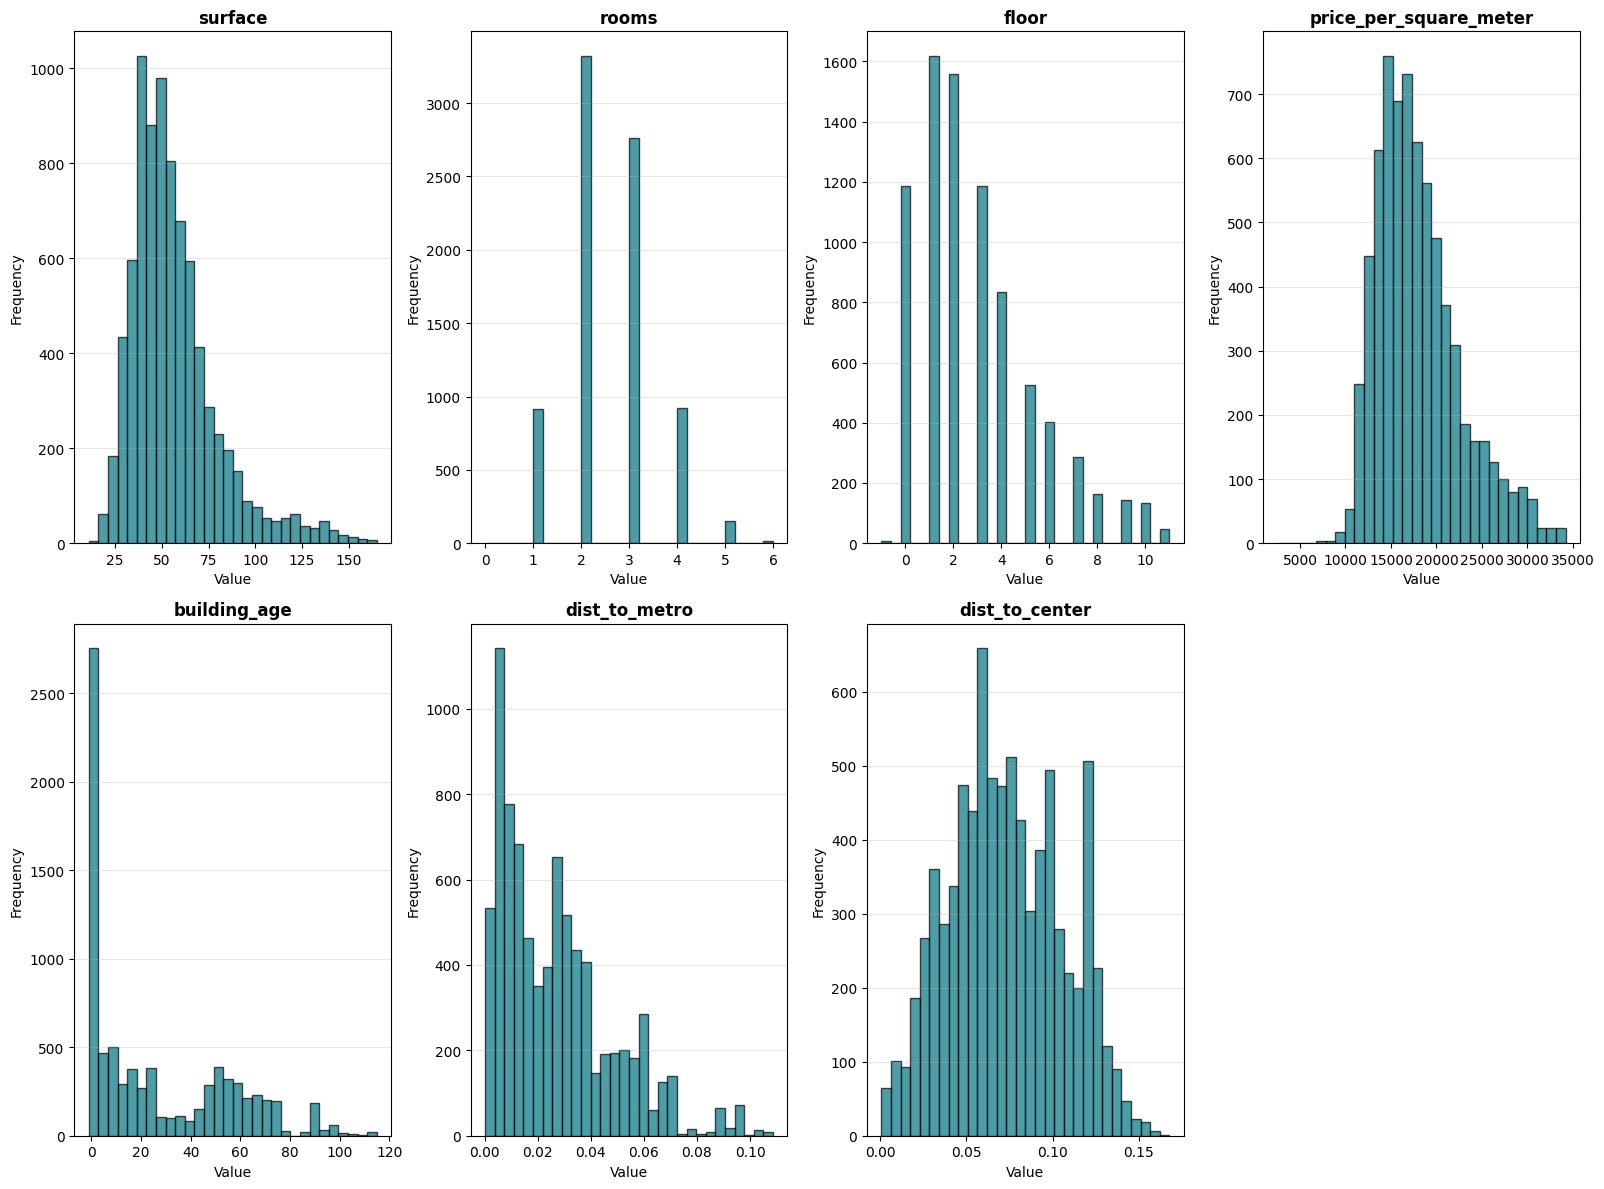


Summary Statistics:
           surface        rooms        floor       market  \
count  8089.000000  8089.000000  8089.000000  8089.000000   
mean     56.205491     2.519965     2.854865     0.747929   
std      23.237431     0.917803     2.447662     0.434228   
min      11.000000     0.000000    -1.000000     0.000000   
25%      40.000000     2.000000     1.000000     0.000000   
50%      51.030000     2.000000     2.000000     1.000000   
75%      65.500000     3.000000     4.000000     1.000000   
max     164.900000     6.000000    11.000000     1.000000   

       price_per_square_meter  building_age  dist_to_metro  dist_to_center  \
count             6949.000000   8089.000000    8089.000000     8089.000000   
mean             18024.453382     26.213994       0.026605        0.073053   
std               4582.427417     28.247245       0.021225        0.032728   
min               2545.454545     -1.000000       0.000172        0.000601   
25%              14693.877551      1.00

In [399]:
# Display distribution of each feature
# Select only numeric columns for distribution analysis, excluding binary columns
binary_cols = ['market', 'river_side']
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in binary_cols]

# Create subplots for each numeric feature
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='#007481')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

### One-hot encoding

In [368]:
# Group districts into 8 tiers by average price per sqm
district_avg_price = df.groupby('district')['price_per_square_meter'].mean().sort_values()

# Rank-based qcut to avoid tie issues
ranks = district_avg_price.rank(method='first')
district_tier = pd.qcut(ranks, q=8, labels=range(8))

# Build group name = all districts in that tier joined by '_'
tier_to_name = {}
for tier in range(8):
    districts_in_tier = district_tier[district_tier == tier].index.tolist()
    tier_to_name[tier] = '_'.join(districts_in_tier)

district_group_map = {d: tier_to_name[int(t)] for d, t in district_tier.items()}
df['district_group'] = df['district'].map(district_group_map)

print("District price tier groups:")
for tier in range(8):
    members = district_tier[district_tier == tier].index.tolist()
    avg = district_avg_price[members].mean()
    print(f"  Tier {tier} (avg {avg:,.0f} PLN/m²): {', '.join(members)}")


District price tier groups:
  Tier 0 (avg 13,513 PLN/m²): Rembertów, Wawer, Białołęka
  Tier 1 (avg 14,961 PLN/m²): Targówek, Ursus
  Tier 2 (avg 16,154 PLN/m²): Bielany, Bemowo
  Tier 3 (avg 17,284 PLN/m²): Włochy, Praga Południe
  Tier 4 (avg 17,726 PLN/m²): Ursynów, Praga Północ
  Tier 5 (avg 19,559 PLN/m²): Ochota, Mokotów
  Tier 6 (avg 20,384 PLN/m²): Wilanów, Wola
  Tier 7 (avg 22,114 PLN/m²): Żoliborz, Śródmieście


In [369]:

# Save a copy before encoding for visualizations that need original categorical columns
df_plot = df.copy()

# Drop original material and district columns — replaced by material_group and district_group
df = df.drop(columns=['material', 'district'])

# One-hot encode material_group and district_group.
df = pd.get_dummies(df, columns=['material_group', 'district_group'], drop_first=False, dtype=int)

print(f"Final feature set ({df.shape[1]} columns): {df.columns.tolist()}")


Final feature set (21 columns): ['surface', 'rooms', 'floor', 'market', 'price_per_square_meter', 'building_age', 'dist_to_metro', 'dist_to_center', 'river_side', 'material_group_brick', 'material_group_modern', 'material_group_other', 'material_group_prefab', 'district_group_Bielany_Bemowo', 'district_group_Ochota_Mokotów', 'district_group_Rembertów_Wawer_Białołęka', 'district_group_Targówek_Ursus', 'district_group_Ursynów_Praga Północ', 'district_group_Wilanów_Wola', 'district_group_Włochy_Praga Południe', 'district_group_Żoliborz_Śródmieście']


## Analysis of the data
- price has near normal distribution

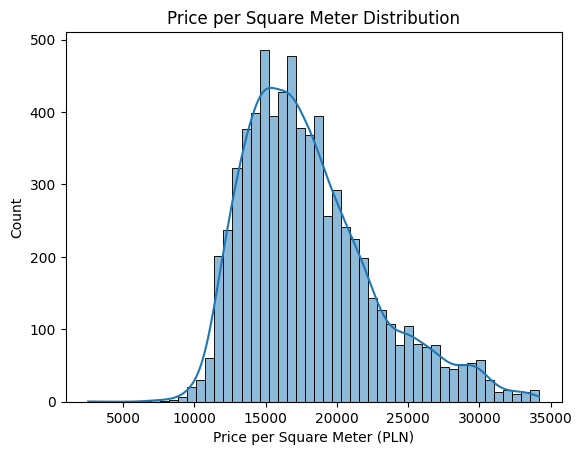

In [370]:
# Visualize price per square meter distribution (only non-null)
sns.histplot(df['price_per_square_meter'].dropna(), bins=50, kde=True)
plt.title("Price per Square Meter Distribution")
plt.xlabel("Price per Square Meter (PLN)")
plt.ylabel("Count")
plt.show()

In [371]:
# Count apartments in each district, split by whether price per square meter is NaN or not
district_price_counts = df_plot.groupby(['district', df_plot['price_per_square_meter'].isna()]).size().unstack(fill_value=0)
district_price_counts.columns = ['price_not_nan', 'price_nan']
district_price_counts = district_price_counts[['price_not_nan', 'price_nan']]  # for column order

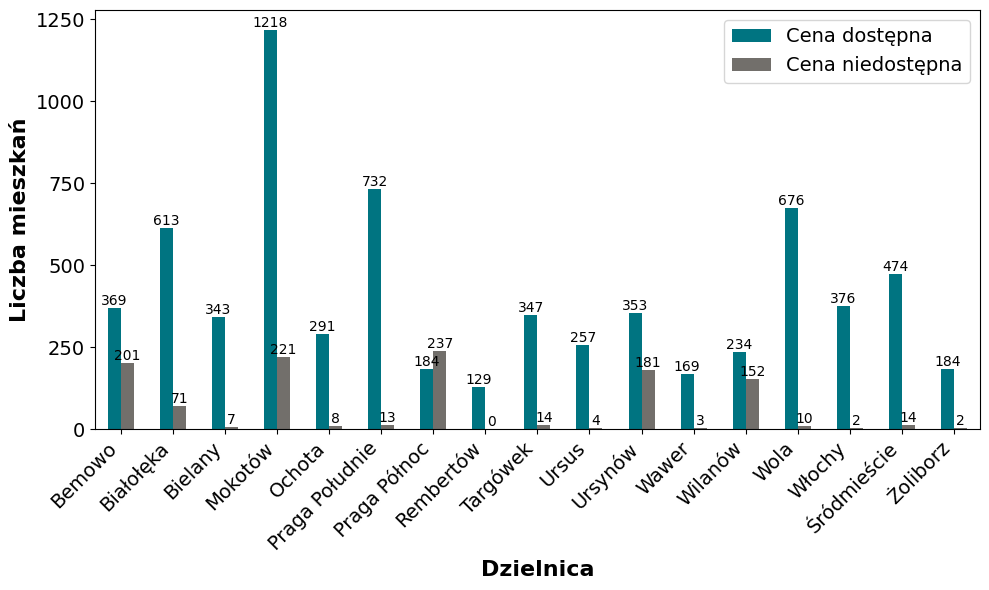

In [372]:
# Bar chart: count of apartments in each district, split by price known/unknown
# Customizable colors and legend labels
color_has_price = '#007481'      # Color for apartments with known price
color_missing_price = '#726F6B'  # Color for apartments with missing price
legend_has_price = 'Cena dostępna'       # Legend label for known price
legend_missing_price = 'Cena niedostępna'   # Legend label for missing price

# Create the plot with custom colors
ax = district_price_counts.plot(kind='bar', stacked=False, figsize=(10, 6),
                               color=[color_has_price, color_missing_price])

# Set labels and formatting
plt.xlabel('Dzielnica', fontsize=16, fontweight='bold')
plt.ylabel('Liczba mieszkań', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))  # Limit to ~6 y-axis ticks

# Update legend with custom labels
ax.legend([legend_has_price, legend_missing_price], loc='upper right', fontsize=14)

# Add value annotations on bars
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [373]:
# Average price per m² in each district (excluding NaN by default)
avg_price_per_square_meter = df_plot.groupby('district')['price_per_square_meter'].mean()

# Optional alignment to district map index used in the next cell
avg_price_per_square_meter = avg_price_per_square_meter.reindex(districts['name'])

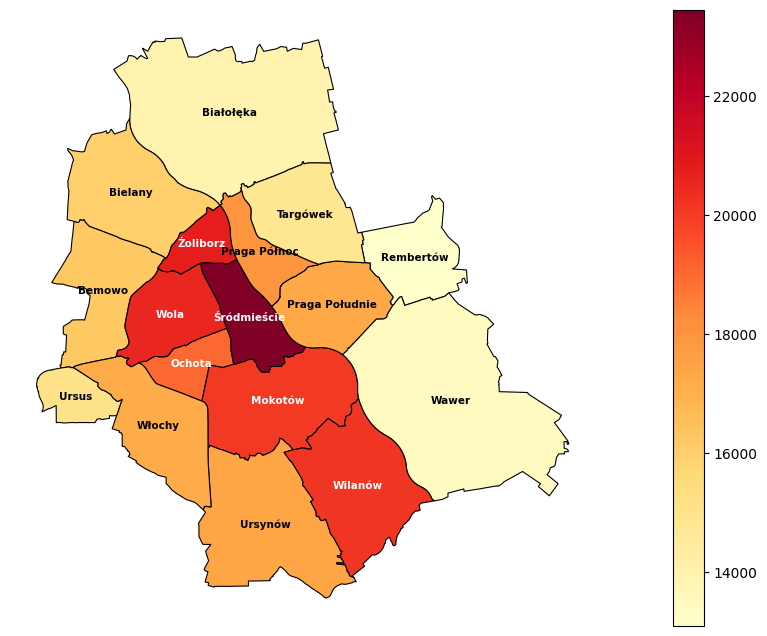

In [374]:
districts_map = districts.set_index('name').copy()
districts_map['avg_price_per_square_meter'] = avg_price_per_square_meter

fig, ax = plt.subplots(figsize=(20, 8))
districts_map.plot(column='avg_price_per_square_meter', cmap='YlOrRd', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
ax.axis('off')

min_val = districts_map['avg_price_per_square_meter'].min()
max_val = districts_map['avg_price_per_square_meter'].max()

for idx, row in districts_map.iterrows():
    if row['geometry'].centroid.is_empty or pd.isna(row['avg_price_per_square_meter']):
        continue
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    normalized_val = (row['avg_price_per_square_meter'] - min_val) / (max_val - min_val)
    text_color = 'white' if normalized_val > 0.5 else 'black'
    plt.text(x, y, idx, fontsize=7.5, ha='center', va='center', fontweight='bold', color=text_color)

plt.show()

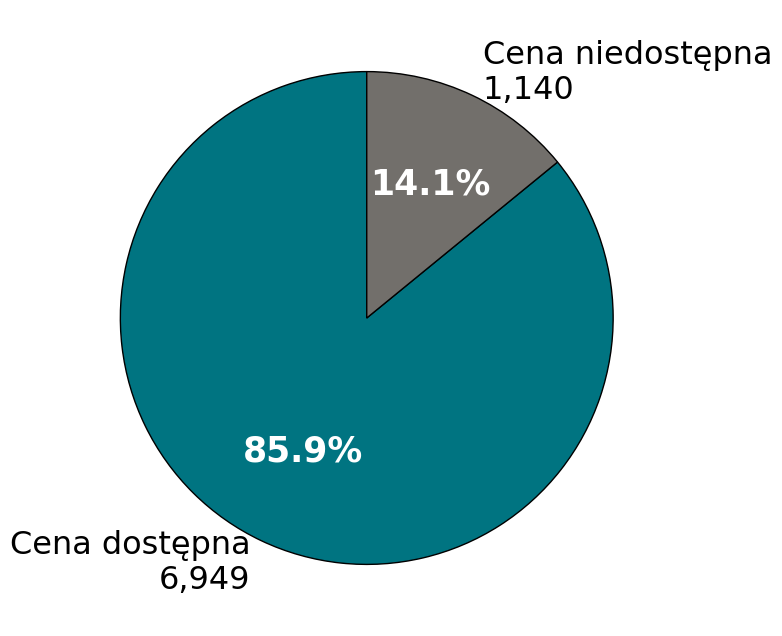

In [375]:
color_has_price = '#007481'
color_missing_price = '#726F6B'

price_counts = df_plot['price_per_square_meter'].isna().value_counts().sort_index()
total_rows = len(df_plot)
has_price_count = price_counts.get(False, 0)
missing_price_count = price_counts.get(True, 0)

labels = [f'Cena dostępna\n{has_price_count:,}', f'Cena niedostępna\n{missing_price_count:,}']
sizes = [has_price_count / total_rows * 100, missing_price_count / total_rows * 100]

plt.figure(figsize=(8, 8))
_, _, autotexts = plt.pie(sizes, labels=labels, colors=[color_has_price, color_missing_price],
                          autopct='%1.1f%%', startangle=90,
                          textprops={'fontsize': 23}, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(25)
plt.show()

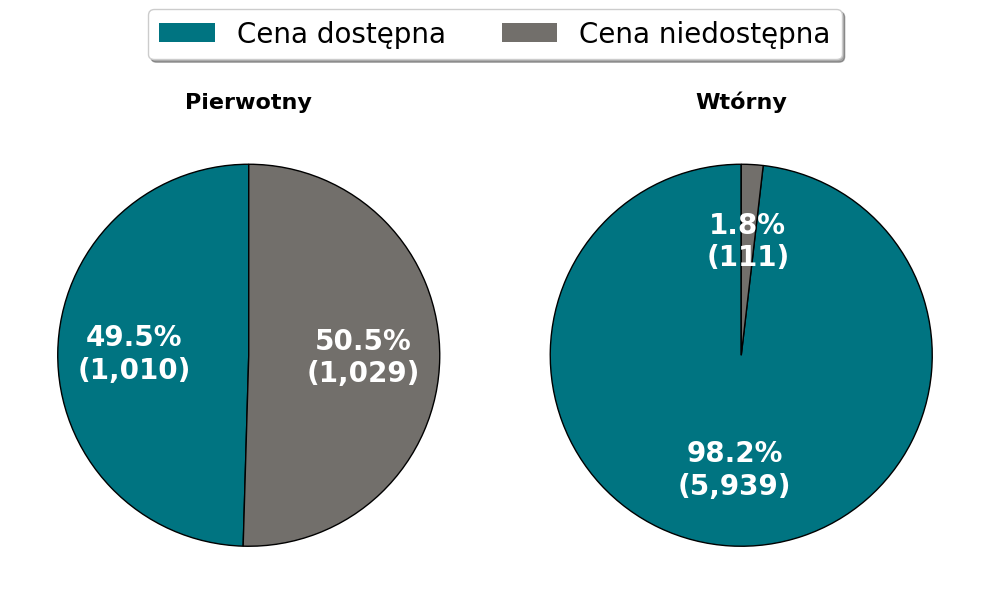

In [376]:
from matplotlib.patches import Patch

color_has_price = '#007481'
color_missing = '#726F6B'

primary_total = len(df_plot[df_plot['market'] == 0])
secondary_total = len(df_plot[df_plot['market'] == 1])

crosstab = pd.crosstab(df_plot['market'], df_plot['price_per_square_meter'].isna())
crosstab.columns = ['has_price', 'missing_price']
crosstab.index = ['Pierwotny', 'Wtórny']

fig, axes = plt.subplots(1, 2, figsize=(10, 7))

for ax, market, total in zip(axes, ['Pierwotny', 'Wtórny'], [primary_total, secondary_total]):
    sizes = [crosstab.loc[market, 'has_price'], crosstab.loc[market, 'missing_price']]
    _, _, autotexts = ax.pie(
        sizes, colors=[color_has_price, color_missing],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total):,})',
        startangle=90, textprops={'fontsize': 18}, wedgeprops={'edgecolor': 'black'}
    )
    for at in autotexts:
        at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(20)
    ax.set_title(market, fontsize=16, fontweight='bold')

legend_elements = [Patch(facecolor=color_has_price, label='Cena dostępna'),
                   Patch(facecolor=color_missing, label='Cena niedostępna')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95),
           ncol=2, fontsize=20, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# Saving dataframe

In [377]:
df.to_excel('../data/properties_modified.xlsx', index=False)


In [378]:
df

,surface,rooms,floor,market,price_per_square_meter,building_age,dist_to_metro,dist_to_center,river_side,material_group_brick,...,material_group_other,material_group_prefab,district_group_Bielany_Bemowo,district_group_Ochota_Mokotów,district_group_Rembertów_Wawer_Białołęka,district_group_Targówek_Ursus,district_group_Ursynów_Praga Północ,district_group_Wilanów_Wola,district_group_Włochy_Praga Południe,district_group_Żoliborz_Śródmieście
0,38.30,2,0,0,12990.000000,-1,0.031542,0.101536,1,0,...,1,0,0,0,1,0,0,0,0,0
1,40.37,2,3,0,17215.754273,1,0.060883,0.086611,0,0,...,1,0,0,0,0,0,0,0,1,0
2,29.52,1,1,0,20447.154472,1,0.067695,0.097462,1,0,...,1,0,0,0,0,0,0,0,1,0
3,53.27,3,4,0,NaN,0,0.012608,0.057783,1,0,...,1,0,0,0,0,0,1,0,0,0
4,28.89,1,2,0,18033.921772,0,0.028400,0.068292,1,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8759,70.40,2,7,1,21164.772727,18,0.007802,0.049942,0,1,...,0,0,0,0,0,0,0,1,0,0
8760,35.24,2,4,1,18161.180477,61,0.026870,0.048701,0,0,...,0,1,0,1,0,0,0,0,0,0
8761,47.10,2,0,1,13375.796178,26,0.036891,0.105248,1,1,...,0,0,0,0,1,0,0,0,0,0
8762,84.10,4,4,1,11296.076100,46,0.005267,0.072380,0,0,...,0,1,0,0,0,0,1,0,0,0
